#Vers 8 Note (04/08/2026):
* (V8) Loại bỏ hàm validate, train với test dùng như cũ
* (V8) Dùng TrivialAugmentWide, có sẵn trong torch vision, có chỗ config cách kích hoạt, đỡ viết code dùng lại đống của tác giả
* (V8) Mở lại Normalize(0.5), dù LNL.py có nhưng nó không hoạt động bên .ipynb (Chưa kiểm chứng)
* (V8) tăng thông số drop_path_rate cho LNL_Ti
* (V8) Dùng TTA để modify hình ảnh khi test
* (V8) Tăng số lượng batch lên 64 + dùng Mixed Precision Training để tối ưu thời gian train?
* (V8) Dùng amp.autocast + amp.GradScaler của MPT?

In [ ]:
!nvidia-smi

Tue Aug  4 08:28:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 45 (delta 4), reused 2 (delta 2), pack-reused 40 (from 1)
Receiving objects: 100% (45/45), 45.99 KiB | 11.50 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [ ]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [ ]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

import torchvision
import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary
import glob
import torch.nn.functional as F

In [ ]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [ ]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  11.5M      0  0:00:22  0:00:22 --:--:-- 13.8M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  9064k      0  0:00:09  0:00:09 --:--:-- 10.8M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  68800      0  0:00:01  0:00:01 --:--:-- 68798


In [ ]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [ ]:
import shutil

In [ ]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [ ]:
# Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
# GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
# Perspective = transforms.RandomPerspective(0.5, p = 0.7)
# HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
# HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
# miror = transforms.RandomHorizontalFlip(p=0.7)
# Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)
# #Chỉ lấy 1 hiệu ứng ngẫu nhiên
# transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]
# single_transform = transforms.RandomChoice(transform_list)



In [ ]:
#train nhanh hơn, dùng Mixed Precision Training nên tự tin đẩy lên 64
batch_size = 64

# TrivialAugmentWide tự động trộn nhiều hiệu ứng nhiễu với cường độ biến thiên, Transformer học cấu trúc vật lý thay vì học vẹt.
# Chuẩn hóa (0.5, 0.5, 0.5) giữ nguyên để đồng bộ phân phối với LNL.py khi khởi tạo pretrained=False.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


#
trainset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/Final_Training/Images',
    transform=train_transform
)

testset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/test',
    transform=test_transform
)
# TÍNH TOÁN TRỌNG SỐ CHO WEIGHTED RANDOM SAMPLER
targets = trainset.targets
class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = torch.from_numpy(weight[targets]).double()
sampler = torch.utils.data.WeightedRandomSampler(samples_weight, len(samples_weight))

# 5. Khởi tạo DataLoader
train_loader = torch.utils.data.DataLoader(
    dataset=trainset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2
    )
test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
    )

In [ ]:
batch = next(iter(train_loader))
train_data = batch[0]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

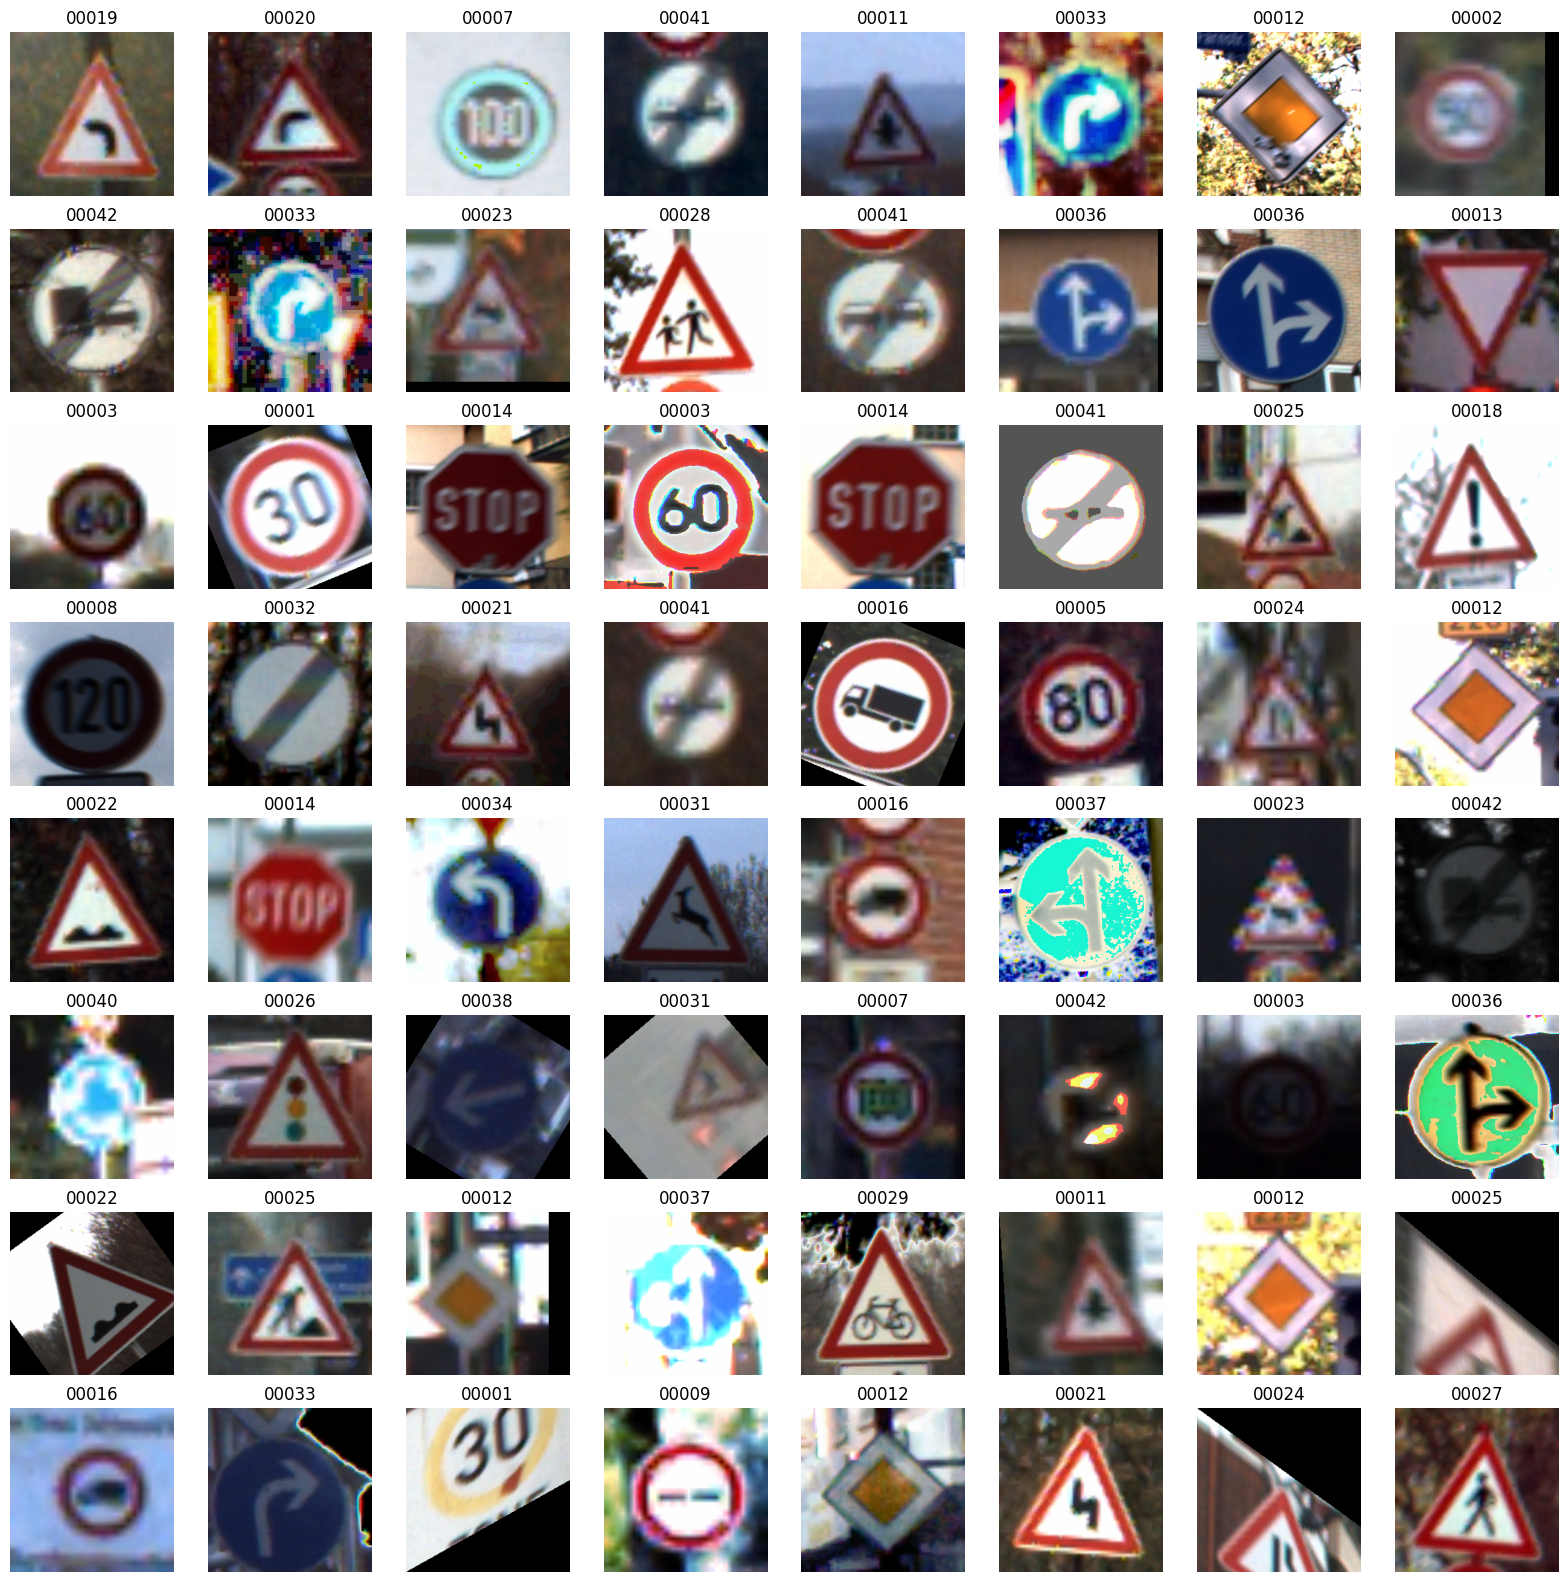

In [ ]:
classes = trainset.classes
plot_images(batch[0], batch[1], classes)

## model

In [ ]:
pip install timm

In [ ]:
pip install einops

In [ ]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [ ]:
#Thêm drop_path_rate=0.1 để ngắt ngẫu nhiên các khối chú ý, chống co-adaptation.
model = small(pretrained=False, drop_path_rate=0.1)
# model = small(pretrained=False)

In [ ]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [ ]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model = model.cuda()

#Code kết nối Drive

In [ ]:
from google.colab import drive
import os

# Kết nối với Google Drive
drive.mount('/content/drive')

# Tạo thư mục lưu trữ
checkpoint_dir = '/content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Thư mục lưu Checkpoint: {checkpoint_dir}")

# THÊM LỆNH NÀY: Tạo thư mục con 'checkpoints' để lưu các file submit an toàn
submit_dir = os.path.join(checkpoint_dir, 'checkpoints')
os.makedirs(submit_dir, exist_ok=True)

print(f"Thư mục lưu Checkpoint tổng (dùng cho MoEx và Resume): {checkpoint_dir}")
print(f"Thư mục lưu file Submit (dùng cho Transforemer): {submit_dir}")

Mounted at /content/drive
Thư mục lưu Checkpoint: /content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy
Thư mục lưu Checkpoint tổng (dùng cho MoEx và Resume): /content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy
Thư mục lưu file Submit (dùng cho Transforemer): /content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy/checkpoints


# Train Locality-iN-Locality


In [ ]:
num_epochs = 40

In [ ]:
# loss = nn.CrossEntropyLoss()
loss = nn.CrossEntropyLoss(label_smoothing=0.1)

# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)

# Thay SGD bằng AdamW

# Tăng Max LR do Batch Size đã tăng gấp đôi (Linear Scaling Rule)
optimizer = optim.AdamW(model.parameters(), lr=0.00001, weight_decay=0.05)


# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
# Thay StepLR bằng OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.002,
    steps_per_epoch=len(train_loader),
    epochs=num_epochs
)
# Khởi tạo công cụ chống Underflow Gradient khi nhân ma trận FP16 (Cú pháp chuẩn PyTorch mới)
scaler = torch.amp.GradScaler('cuda')

##Mảng lưu trữ ghi chép số diểm sau mỗi vòng - Standard

In [ ]:
# Danh sách lưu trữ lịch sử để vẽ biểu đồ
history_train_loss = []
history_test_acc = []

##BLOCK CALL CHECKPOINTS

In [ ]:
checkpoint_path = '/content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy/khoi_transformer_model_v8.pth'
start_epoch = 0

# Kiểm tra xem có file kết quả lưu ở lần chạy trước không
if os.path.exists(checkpoint_path):
    print(f"Đang phục hồi mô hình từ: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)

    # Bơm lại trọng số và thuật toán
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

   # Phục hồi thêm trạng thái của GradScaler để tránh lỗi Underflow khi resume
    if 'scaler_state_dict' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])

    history_train_loss = checkpoint.get('history_train_loss', [])
    history_test_acc = checkpoint.get('history_test_acc', [])

    start_epoch = checkpoint['epoch'] + 1
    print(f"Phục hồi thành công! Sẽ chạy tiếp từ Epoch {start_epoch + 1}")
else:
    print("Không có kết quả cũ, bắt đầu huấn luyện từ Epoch 1.")

Không có kết quả cũ, bắt đầu huấn luyện từ Epoch 1.


#Train mô hình LNL


In [ ]:
total_batch = len(train_loader)

for epoch in range(start_epoch, num_epochs):

    model.train()
    total_loss = 0

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        optimizer.zero_grad()

        #Tự động chuyển các lớp Conv/Linear sang không gian FP16 để gia tốc trên lõi Tensor Cores.
        with autocast('cuda'):
            outputs = model(X)
            cost = loss(outputs, Y)

        # Nhân hệ số gradient để không bị mất mát dữ liệu nhỏ trong FP16, sau đó tính đạo hàm.
        scaler.scale(cost).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += cost.item()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f, LR: %.5f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item(), scheduler.get_last_lr()[0]))

    # Tính Loss trung bình của cả Epoch này và lưu lại
    avg_train_loss = total_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1:02d}/{num_epochs}] - Train Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}')

    #redundant line, forgot to delete when trained
    # print(f'Epoch [{epoch+1:02d}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}')

    submit_filename = os.path.join(checkpoint_dir, f'khoi_model_epoch_{epoch+1:02d}.pth')
    torch.save(model.state_dict(), submit_filename)

    print("Hoàn tất huấn luyện!")

    # Lưu đủ 5 món để Resume
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history_train_loss': history_train_loss,
        'history_test_acc': history_test_acc
    }, checkpoint_path)
    print(f"Đã sao lưu an toàn Epoch {epoch+1} vào Drive!")
print(f"Es ist done!")

Epoch [1/40], lter [200/613], Loss: 2.941308, LR: 0.00008
Epoch [1/40], lter [400/613], Loss: 2.116380, LR: 0.00009
Epoch [1/40], lter [600/613], Loss: 1.209444, LR: 0.00011
Epoch [01/40] - Train Loss: 2.3301 | LR: 0.00011
Epoch [01/40] - Train Loss: 2.3301 | LR: 0.00011
Hoàn tất huấn luyện!
Đã sao lưu an toàn Epoch 1 vào Drive!
Epoch [2/40], lter [200/613], Loss: 1.294457, LR: 0.00014
Epoch [2/40], lter [400/613], Loss: 1.166532, LR: 0.00017
Epoch [2/40], lter [600/613], Loss: 0.882366, LR: 0.00021
Epoch [02/40] - Train Loss: 1.0336 | LR: 0.00021
Epoch [02/40] - Train Loss: 1.0336 | LR: 0.00021
Hoàn tất huấn luyện!
Đã sao lưu an toàn Epoch 2 vào Drive!
Epoch [3/40], lter [200/613], Loss: 0.973588, LR: 0.00025
Epoch [3/40], lter [400/613], Loss: 0.904410, LR: 0.00030
Epoch [3/40], lter [600/613], Loss: 0.901529, LR: 0.00036
Epoch [03/40] - Train Loss: 0.9271 | LR: 0.00036
Epoch [03/40] - Train Loss: 0.9271 | LR: 0.00036
Hoàn tất huấn luyện!
Đã sao lưu an toàn Epoch 3 vào Drive!
Epoch [

## Test Transformer + Test-Time Augmentation


In [ ]:
print("Bắt đầu quy trình duyệt Checkpoint trên tập Test...")

best_acc = 0.0
best_epoch_file = ""

# Quét toàn bộ file trọng số đã lưu theo thứ tự epoch
checkpoint_files = sorted(glob.glob(os.path.join(checkpoint_dir, 'khoi_model_epoch_*.pth')))

for ckpt_path in checkpoint_files:
    # Nạp "bộ não" vào khung hình - Mô phỏng chính xác hành vi chấm bài của Giảng viên
    model.load_state_dict(torch.load(ckpt_path))
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()

            # [LÝ DO TTA]: Khử nhiễu bằng cách lấy trung bình dự đoán của 2 phiên bản hình ảnh
            # 1. Output chuẩn
            outputs_orig = model(images)
            prob_orig = F.softmax(outputs_orig, dim=1)

            # 2. Output phóng to 5% (Mô phỏng lại việc đưa mắt tới gần biển báo)
            images_scaled = F.interpolate(images, scale_factor=1.05, mode='bilinear', align_corners=False)
            images_scaled = transforms.CenterCrop(224)(images_scaled)
            outputs_scaled = model(images_scaled)
            prob_scaled = F.softmax(outputs_scaled, dim=1)

            # Tổ hợp xác suất Ensemble
            prob_avg = (prob_orig + prob_scaled) / 2.0
            _, predicted = torch.max(prob_avg, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * float(correct) / total
    print(f'Test Accuracy ({os.path.basename(ckpt_path)}): {acc:.2f}%')

    if acc > best_acc:
        best_acc = acc
        best_epoch_file = ckpt_path

print("-" * 50)
print(f'TRỌNG SỐ TỐT NHẤT: {best_acc:.2f}% tại file: {os.path.basename(best_epoch_file)}')

Bắt đầu quy trình duyệt Checkpoint trên tập Test...
Test Accuracy (khoi_model_epoch_01.pth): 93.15%
Test Accuracy (khoi_model_epoch_02.pth): 96.55%
Test Accuracy (khoi_model_epoch_03.pth): 98.24%
Test Accuracy (khoi_model_epoch_04.pth): 97.56%
Test Accuracy (khoi_model_epoch_05.pth): 97.18%
Test Accuracy (khoi_model_epoch_06.pth): 96.47%
Test Accuracy (khoi_model_epoch_07.pth): 98.16%
Test Accuracy (khoi_model_epoch_08.pth): 97.24%
Test Accuracy (khoi_model_epoch_09.pth): 97.68%
Test Accuracy (khoi_model_epoch_10.pth): 96.90%
Test Accuracy (khoi_model_epoch_11.pth): 96.39%
Test Accuracy (khoi_model_epoch_12.pth): 98.01%
Test Accuracy (khoi_model_epoch_13.pth): 97.80%
Test Accuracy (khoi_model_epoch_14.pth): 98.43%
Test Accuracy (khoi_model_epoch_15.pth): 98.78%
Test Accuracy (khoi_model_epoch_16.pth): 98.42%
Test Accuracy (khoi_model_epoch_17.pth): 98.50%
Test Accuracy (khoi_model_epoch_18.pth): 98.69%
Test Accuracy (khoi_model_epoch_19.pth): 97.89%
Test Accuracy (khoi_model_epoch_20.p

# FGSM attack

In [ ]:
# model.eval()

# correct = 0
# total = 0

# atk = FGSM(model, eps=0.01)

# for images, labels in test_loader:

#     images = atk(images, labels).cuda()
#     outputs = model(images)

#     _, predicted = torch.max(outputs.data, 1)

#     total += labels.size(0)
#     correct += (predicted == labels.cuda()).sum()

# print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

# PGD attack

In [ ]:
# model.eval()

# correct = 0
# total = 0

# atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

# for images, labels in test_loader:

#     images = atk(images, labels).cuda()
#     outputs = model(images)

#     _, predicted = torch.max(outputs.data, 1)

#     total += labels.size(0)
#     correct += (predicted == labels.cuda()).sum()

# print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

# train LNL-MoEx
- 2 models khác nhau nên chạy 2 cái .pth nhau a zai

##Mảng lưu trữ ghi chép số diểm sau mỗi vòng

In [ ]:
import matplotlib.pyplot as plt

# Danh sách lưu trữ lịch sử để vẽ biểu đồ
history_train_loss_moex = []
history_test_acc_moex = []

In [ ]:
from LNL_MoEx import LNL_MoEx_Ti as small_moex
model_moex = small_moex(pretrained=False)
model_moex.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

/content/Locality-iN-Locality/models/tnt_moex.py:312: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/Locality-iN-Locality/models/tnt_moex.py:323: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/Locality-iN-Locality/models/tnt_moex.py:334: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


In [ ]:
model_moex = model_moex.cuda()

In [ ]:
import time
# time.clock_gettime()

In [ ]:
num_epochs_moex = 40
moex_lam = .9
moex_prob = .7

In [ ]:
loss_moex = nn.CrossEntropyLoss(label_smoothing=0.1)

# optimizer_moex = optim.SGD(model_moex.parameters(), lr=0.007, momentum=0.9)
# Thay SGD bằng AdamW
optimizer_moex = optim.AdamW(model_moex.parameters(), lr=0.0005, weight_decay=0.05)

# scheduler_moex = torch.optim.lr_scheduler.StepLR(optimizer_moex, step_size=30, gamma=0.1)
# Thay StepLR bằng OneCycleLR
scheduler_moex = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_moex,
    max_lr=0.001,
    steps_per_epoch=len(train_loader),
    epochs=num_epochs_moex
)

##BLOCK CALL CHECKPOINTS

In [ ]:
import torch

checkpoint_path_moex = '/content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy/khoi_LNL_MoEx_model_v7.pth'
# checkpoint_path_moex = './khoi_LNL_MoEx_model_v6.pth'
start_epoch_moex = 0

# Kiểm tra xem có file kết quả lưu ở lần chạy trước không
if os.path.exists(checkpoint_path_moex):
    print(f"Đang phục hồi mô hình từ: {checkpoint_path_moex}")
    checkpoint = torch.load(checkpoint_path_moex)

    # Bơm lại trọng số và thuật toán
    model_moex.load_state_dict(checkpoint['model_state_dict'])
    optimizer_moex.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler_moex.load_state_dict(checkpoint['scheduler_state_dict'])

    # Phục hồi luôn cả lịch sử vẽ đồ thị cũ (nếu có)
    history_train_loss_moex = checkpoint.get('history_train_loss', [])
    history_test_acc_moex = checkpoint.get('history_test_acc', [])

    # Xác định chạy tiếp từ vòng nào
    start_epoch_moex = checkpoint['epoch'] + 1
    print(f"Phục hồi thành công! Sẽ chạy tiếp từ Epoch {start_epoch + 1}")
else:
    print("Không có kết quả cũ, bắt đầu huấn luyện từ Epoch 1.")

Không có kết quả cũ, bắt đầu huấn luyện từ Epoch 1.


In [ ]:
# 1. KHAI BÁO BIẾN THEO DÕI KỶ LỤC CHO MOEX
best_val_acc_moex = 0.0
for epoch in range(start_epoch_moex, num_epochs_moex):

    model_moex.train()
    total_loss_moex = 0
    total_batch = len(trainset) // batch_size

    for i, (input_imgs, target_labels) in enumerate(train_loader):
        input_imgs = input_imgs.cuda()
        target_labels = target_labels.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input_imgs.size(0), device=input_imgs.device)
            with torch.no_grad():
                target_a = target_labels
                target_b = target_labels[swap_index]
            output = model_moex(input_imgs, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss_moex(output, target_a) * lam + loss_moex(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model_moex(input_imgs)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss_moex(output, target_labels)

        # compute gradient and do SGD step

        optimizer_moex.zero_grad()
        cost.backward()
        optimizer_moex.step()

        # Cập nhật learning rate scheduler
        scheduler_moex.step()
        total_loss_moex += cost.item()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs_moex, i+1, total_batch, cost.item()))
        # Tính Loss trung bình của cả Epoch này và lưu lại
    avg_train_loss_moex = total_loss_moex / len(train_loader)
    history_train_loss_moex.append(avg_train_loss_moex)


    # 2. TEST (ĐÁNH GIÁ MÔ HÌNH SAU MỖI EPOCH)
    model_moex.eval()
    val_correct_moex = 0
    # val_total_samples_moex = 0
    val_total_moex = 0


    with torch.no_grad(): # Tắt tính toán ngược để không tốn RAM
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model_moex(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total_moex += labels.size(0)
            val_correct_moex += (predicted == labels).sum().item()

    # Tính Accuracy
    epoch_val_acc_moex = 100 * float(val_correct_moex) / val_total_moex
    history_test_acc_moex.append(epoch_val_acc_moex)

    print(f"Tổng kết Epoch {epoch+1}: Train Loss = {avg_train_loss_moex:.4f} | Val Accuracy = {epoch_val_acc_moex:.2f}%")


    # 3. CẬP NHẬT SCHEDULER & LƯU TRỮ VÀO DRIVE


    # Lưu đầy đủ trạng thái để có thể Resume
    torch.save({
        'epoch': epoch,
        'model_state_dict': model_moex.state_dict(),
        'optimizer_state_dict': optimizer_moex.state_dict(),
        'scheduler_state_dict': scheduler_moex.state_dict(),
        'history_train_loss': history_train_loss_moex,
        'history_test_acc': history_test_acc_moex
    }, checkpoint_path_moex)

    print(f"Đã sao lưu an toàn Epoch {epoch+1} (File: LNL_MoEx_latest.pth) vào Drive!\n" + "-"*50)
    # ================= LƯU FILE NỘP BÀI (CHỈ TRỌNG SỐ SẠCH) =================
    if epoch_val_acc_moex > best_val_acc_moex:
        best_val_acc_moex = epoch_val_acc_moex

        # Đã thêm tag "MoEx" để giáo viên không nhầm lẫn
        submit_filename = f'/content/drive/MyDrive/DEEPLEARNING_Master_GiuaKy/khoi_MoEx_epoch{epoch+1}_val_acc{best_val_acc_moex:.2f}_submit.pth'

        # Trích xuất state_dict nguyên chất
        torch.save(model_moex.state_dict(), submit_filename)
        print(f"🌟 Đạt kỷ lục mới! Đã xuất file nộp bài sạch tại: {submit_filename}")

    print("-" * 50)

Epoch [1/40], lter [200/612], Loss: 3.522294


KeyboardInterrupt: 


###Vẽ biểu đồ kiểm tra Loss learning curve

In [ ]:
# Vẽ biểu đồ Train Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_train_loss_moex, marker='o', color='red', label='Train Loss')
plt.title('Đồ thị suy giảm Loss - LNL_MoEx_S')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Vẽ biểu đồ Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_test_acc_moex, marker='s', color='blue', label='Test Accuracy')
plt.title('Đồ thị tăng trưởng Accuracy - LNL_MoEx_S')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
# Kẻ một đường chỉ tiêu 99.5% để dễ quan sát mục tiêu
plt.axhline(y=99.5, color='green', linestyle='--', label='Mục tiêu 99.5%')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Test_Clean data_Moex

In [ ]:
# model_moex.eval()
# correct_clean = 0
# total_clean = 0

# for images, labels in test_loader:

#     images = images.cuda()
#     labels = labels.cuda()
#     outputs = model_moex(images)

#     _, predicted = torch.max(outputs.data, 1)

#     total_clean += labels.size(0)
#     correct_clean += (predicted == labels.cuda()).sum()

# print('LNL_MoEx Standard accuracy: %.2f %%' % (100 * float(correct_clean) / total_clean))

model_moex.eval()
correct_clean = 0
total_clean = 0

with torch.no_grad(): # BỔ SUNG DÒNG NÀY
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()
        outputs = model_moex(images)

        _, predicted = torch.max(outputs.data, 1)

        total_clean += labels.size(0)
        correct_clean += (predicted == labels).sum().item() # Bỏ .cuda() ở labels vì đã map ở trên

print('LNL_MoEx Standard accuracy: %.2f %%' % (100 * float(correct_clean) / total_clean))

# Number of Parameters







In [ ]:
# pip install ptflops

In [ ]:
# pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [ ]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))
